<a href="https://colab.research.google.com/github/yhkovska/Ecommerce-Analytics-Python/blob/main/Ecommerce_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# connecting Google Drive
from google.colab import drive
drive.mount("/content/drive")

# changing work folder
%cd /content/drive/MyDrive/Mate/ModuleTasks

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Mate/ModuleTasks


##**Data overview**

In [ ]:
# uploading and checking datasets

df_events = pd.read_csv("events.csv")
df_countries = pd.read_csv("countries.csv")
df_products = pd.read_csv("products.csv")

print(f"Events Data:\n{df_events.head()}")
print(f"\nCountries Data:\n{df_countries.head()}")
print(f"\nProducts Data:\n{df_products.head()}")

Events Data:
    Order ID Order Date   Ship Date Order Priority Country Code  Product ID  \
0  100640618  10/8/2014  10/18/2014              M          NOR        2103   
1  100983083  8/11/2016   8/11/2016              C          SRB        2103   
2  101025998  7/18/2014   8/11/2014              M          NaN        7940   
3  102230632  5/13/2017   6/13/2017              L          MNE        2455   
4  103435266  8/11/2012   9/18/2012              H          SRB        1270   

  Sales Channel  Units Sold  Unit Price  Unit Cost  
0        Online       650.0      205.70     117.11  
1       Offline      1993.0      205.70     117.11  
2        Online      4693.0      668.27     502.54  
3        Online      1171.0      109.28      35.84  
4       Offline      7648.0       47.45      31.79  

Countries Data:
             name alpha-2 alpha-3   region       sub-region
0     Afghanistan      AF     AFG     Asia    Southern Asia
1   Åland Islands      AX     ALA   Europe  Northern Euro

In [ ]:
# rows and columns overview

print("Events Data Shape:", df_events.shape)
print("Countries Data Shape:", df_countries.shape)
print("Products Data Shape:", df_products.shape)

Events Data Shape: (1330, 10)
Countries Data Shape: (249, 5)
Products Data Shape: (12, 2)


In [ ]:
# analyzing basic info of all tables

print(f"Events DF info:\n{df_events.info()}")
print(f"\nCountries DF info:\n{df_countries.info()}")
print(f"\nProducts DF info:\n{df_products.info()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        1330 non-null   int64  
 1   Order Date      1330 non-null   object 
 2   Ship Date       1330 non-null   object 
 3   Order Priority  1330 non-null   object 
 4   Country Code    1248 non-null   object 
 5   Product ID      1330 non-null   int64  
 6   Sales Channel   1330 non-null   object 
 7   Units Sold      1328 non-null   float64
 8   Unit Price      1330 non-null   float64
 9   Unit Cost       1330 non-null   float64
dtypes: float64(3), int64(2), object(5)
memory usage: 104.0+ KB
Events DF info:
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        249 non-null    object
 1   alpha-2     248 non-null    object
 2  

In [ ]:
# analyzing data types

print(f"Events DF Data type:\n{df_events.dtypes}")
print(f"\nCountries DF Data type:\n{df_countries.dtypes}")
print(f"\nProducts DF Data type:\n{df_products.dtypes}")

Events DF Data type:
Order ID            int64
Order Date         object
Ship Date          object
Order Priority     object
Country Code       object
Product ID          int64
Sales Channel      object
Units Sold        float64
Unit Price        float64
Unit Cost         float64
dtype: object

Countries DF Data type:
name          object
alpha-2       object
alpha-3       object
region        object
sub-region    object
dtype: object

Products DF Data type:
id            int64
item_type    object
dtype: object


### Datasets description
1. Column names need to be standardized according to proper naming conventions.
2. Product_id / id and Country_Code / alpha-3 are key columns used to join all three tables.
3. The Order_Date and Ship_Date columns should be converted to datetime format.
4. Duplicate records should be removed, and missing values should be imputed.

##**Data cleaning**

In [ ]:
# changing columns naming due to code style

df_events.columns = df_events.columns.str.lower().str.replace(" ", "_")
df_countries.columns = df_countries.columns.str.lower().str.replace(" ", "_")
df_products.columns = df_products.columns.str.lower().str.replace(" ", "_")

In [ ]:
# converting the date columns to datetime

df_events["order_date"] = pd.to_datetime(df_events["order_date"], errors='coerce')
df_events["ship_date"] = pd.to_datetime(df_events["ship_date"], errors='coerce')

In [ ]:
# checking for missing values and calculating their percentage

print(f"\nNumber of missing values in the df_events table:\n{df_events.isna().sum()}")
print(f"\nShare of missing values in the df_events table:\n{df_events.isna().sum() / df_events.shape[0] * 100}")

print(f"\nNumber of missing values in the df_countries table:\n{df_countries.isna().sum()}")
print(f"\nShare of missing values in the df_countries table:\n{df_countries.isna().sum() / df_countries.shape[0] * 100}")

print(f"\nNumber of missing values in the df_products table:\n{df_products.isna().sum()}")
print(f"\nShare of missing values in the df_products table:\n{df_products.isna().sum() / df_products.shape[0] * 100}")


Number of missing values in the df_events table:
order_id           0
order_date         0
ship_date          0
order_priority     0
country_code      82
product_id         0
sales_channel      0
units_sold         2
unit_price         0
unit_cost          0
dtype: int64

Share of missing values in the df_events table:
order_id          0.000000
order_date        0.000000
ship_date         0.000000
order_priority    0.000000
country_code      6.165414
product_id        0.000000
sales_channel     0.000000
units_sold        0.150376
unit_price        0.000000
unit_cost         0.000000
dtype: float64

Number of missing values in the df_countries table:
name          0
alpha-2       1
alpha-3       0
region        1
sub-region    1
dtype: int64

Share of missing values in the df_countries table:
name          0.000000
alpha-2       0.401606
alpha-3       0.000000
region        0.401606
sub-region    0.401606
dtype: float64

Number of missing values in the df_products table:
id           

In [ ]:
# cleaning missing values

df_events_clean = df_events.dropna()
df_countries_clean = df_countries.dropna()

print(f"Number of missing values in the df_events table:\n{df_events_clean.isna().sum()}")
print(f"\nNumber of missing values in the df_events table:\n{df_countries_clean.isna().sum()}")

Number of missing values in the df_events table:
order_id          0
order_date        0
ship_date         0
order_priority    0
country_code      0
product_id        0
sales_channel     0
units_sold        0
unit_price        0
unit_cost         0
dtype: int64

Number of missing values in the df_events table:
name          0
alpha-2       0
alpha-3       0
region        0
sub-region    0
dtype: int64


The **df_events** table contains missing values in the *country_code* column - 82 rows, which account for **6%** of the entire dataset. The absence of this data may be related to data entry errors or missing information at the time the order was placed.

Since the values in this column depend on the data in the subsequent columns, we cannot fill them using forward or backward filling. Therefore, we remove these rows entirely.

The same table also contains 2 missing values in the *units_sold* column, representing less than **0.15%** of the data, so these rows can also be removed.

In the **df_products** table, there are missing values in the *alpha-2, region*, and *sub-region* columns - one value each, accounting for **1.2%** in total. These rows can be removed as well.



In [ ]:
# checking for duplicates

print(f"Number of duplicated rows in df_events: {df_events.duplicated().sum()}")
print(f"Number of duplicated rows in df_countries: {df_countries.duplicated().sum()}")
print(f"Number of duplicated rows in df_products: {df_products.duplicated().sum()}")

Number of duplicated rows in df_events: 0
Number of duplicated rows in df_countries: 0
Number of duplicated rows in df_products: 0


In [ ]:
# removing extra whitespace and convert text to lowercase

df_events['country_code'] = df_events['country_code'].str.strip()
df_events['sales_channel'] = df_events['sales_channel'].str.strip().str.lower()

df_countries['name'] = df_countries['name'].str.strip()
df_countries['alpha-2'] = df_countries['alpha-2'].str.strip()
df_countries['alpha-3'] = df_countries['alpha-3'].str.strip()
df_countries['region'] = df_countries['region'].str.strip()
df_countries['sub-region'] = df_countries['sub-region'].str.strip()

df_products['item_type'] = df_products['item_type'].str.strip()

## **Data analysis and visualization**

In [ ]:
# joining all tables into one dataframe
df_merged = pd.merge(df_events, df_countries[["name", "alpha-3", "region", "sub-region"]], left_on="country_code", right_on="alpha-3", how="inner")
df = pd.merge(df_merged, df_products, left_on="product_id", right_on="id", how="inner")

# deleting spare columns and renaming another column
df = df.drop(columns=["alpha-3", "id"])
df = df.rename(columns={"name": "country"})

# changing naming and adding new columns due to code style and usability
df.columns = df.columns.str.lower().str.replace(" ", "_")

df.dropna()
df.loc[:, "revenue"] = df["units_sold"] * df["unit_price"]
df.loc[:, "cost"] = df["units_sold"] * df["unit_cost"]
df.loc[:, "profit"] = df["revenue"] - df["cost"]

# checking full dataframe
df.head()

,order_id,order_date,ship_date,order_priority,country_code,product_id,sales_channel,units_sold,unit_price,unit_cost,country,region,sub-region,item_type,revenue,cost,profit
0,100640618,2014-10-08,2014-10-18,M,NOR,2103,online,650.0,205.70,117.11,Norway,Europe,Northern Europe,Cereal,133705.00,76121.50,57583.50
1,100983083,2016-08-11,2016-08-11,C,SRB,2103,offline,1993.0,205.70,117.11,Serbia,Europe,Southern Europe,Cereal,409960.10,233400.23,176559.87
2,102230632,2017-05-13,2017-06-13,L,MNE,2455,online,1171.0,109.28,35.84,Montenegro,Europe,Southern Europe,Clothes,127966.88,41968.64,85998.24
3,103435266,2012-08-11,2012-09-18,H,SRB,1270,offline,7648.0,47.45,31.79,Serbia,Europe,Southern Europe,Beverages,362897.60,243129.92,119767.68
4,103450715,2015-03-15,2015-04-18,H,SVK,8681,online,2220.0,651.21,524.96,Slovakia,Europe,Eastern Europe,Office Supplies,1445686.20,1165411.20,280275.00


In [ ]:
# basic metrics
total_revenue = (df['units_sold'] * df['unit_price']).sum()
total_cost = (df['units_sold'] * df['unit_cost']).sum()
avg_ship = (df['ship_date'] - df['order_date']).mean().days

print(f"Total orders: {df['order_id'].nunique()}")
print(f"Total countries: {df['country'].nunique()}")
print(f"Total units sold: {df['units_sold'].sum()}")
print(f"Total revenue: {total_revenue}")
print(f"Total profit: {total_revenue - total_cost}")
print(f"Total cost: {total_cost}")
print(f"Average shipping days: {avg_ship} days")

Total orders: 1248
Total countries: 45
Total units sold: 6171671.0
Total revenue: 1598983761.2600002
Total profit: 473709035.0600002
Total cost: 1125274726.2
Average shipping days: 24 days


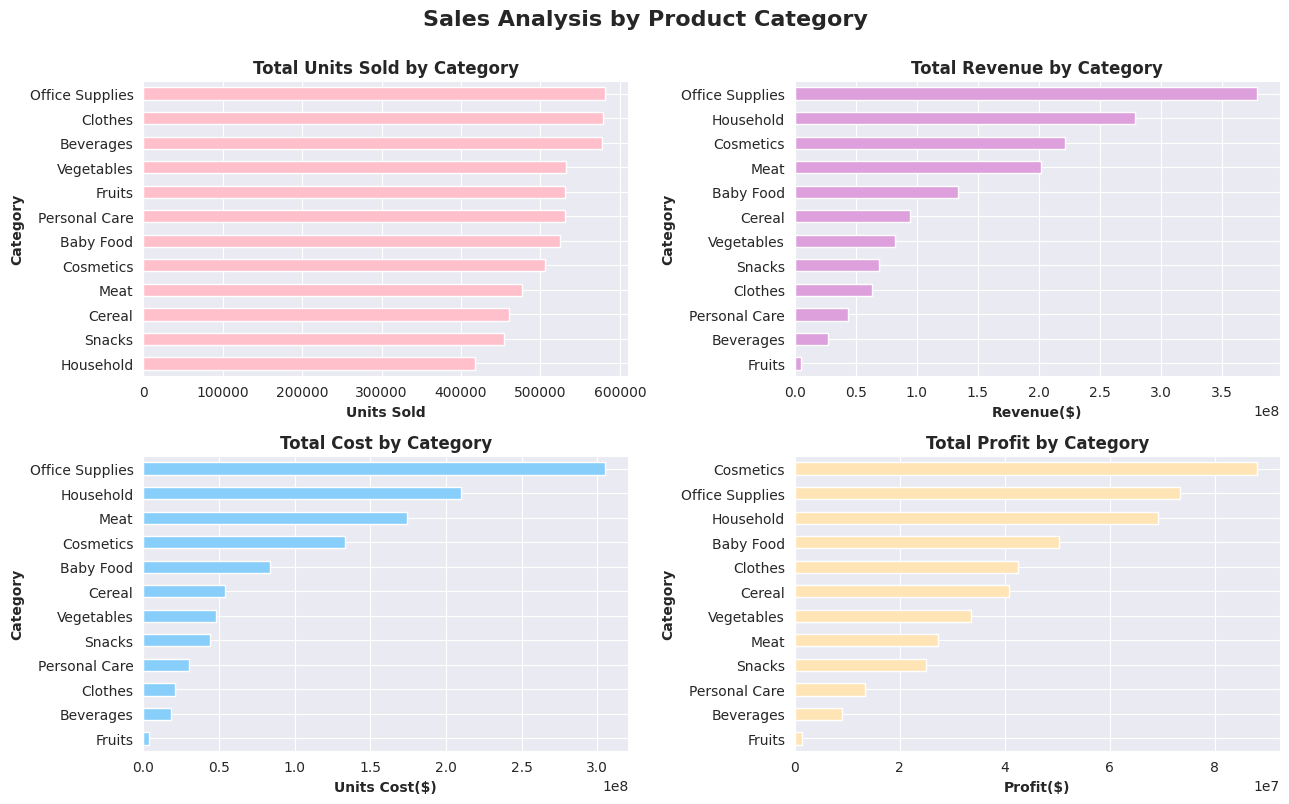

In [ ]:
# category analysis
category_grouped = df.groupby("item_type")[["units_sold","revenue","cost","profit"]].sum().sort_values(by="units_sold",ascending=True)

sns.set_style("darkgrid")
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle('Sales Analysis by Product Category', fontweight="bold", fontsize=16, y=1)

# First subplot -  Bar plot of Units Sold by Category
ax = axes[0, 0]
category_grouped['units_sold'].sort_values().plot(kind='barh', ax=ax, color='pink')

ax.set(title='Total Units Sold by Category', xlabel='Units Sold', ylabel='Category')
ax.title.set_fontweight('semibold')
ax.xaxis.label.set_fontweight('semibold')
ax.yaxis.label.set_fontweight('semibold')

# Second subplot -  Bar plot of Revenue by Category
ax = axes[0, 1]
category_grouped['revenue'].sort_values().plot(kind='barh', ax=ax, color='plum')

ax.set(title='Total Revenue by Category', xlabel='Revenue($)', ylabel='Category')
ax.title.set_fontweight('semibold')
ax.xaxis.label.set_fontweight('semibold')
ax.yaxis.label.set_fontweight('semibold')

# Third subplot -  Bar plot of Cost by Category
ax = axes[1, 0]
category_grouped['cost'].sort_values().plot(kind='barh', ax=ax, color='lightskyblue')

ax.set(title='Total Cost by Category', xlabel='Units Cost($)', ylabel='Category')
ax.title.set_fontweight('semibold')
ax.xaxis.label.set_fontweight('semibold')
ax.yaxis.label.set_fontweight('semibold')

# Fourth subplot -  Bar plot of Profit by Category
ax = axes[1, 1]
category_grouped['profit'].sort_values().plot(kind='barh', ax=ax, color='moccasin')

ax.set(title='Total Profit by Category', xlabel='Profit($)', ylabel='Category')
ax.title.set_fontweight('semibold')
ax.xaxis.label.set_fontweight('semibold')
ax.yaxis.label.set_fontweight('semibold')

plt.tight_layout()
plt.show()

## **Report**

**Units Sold:**

The highest number of units sold is in *Office Supplies*, *Clothes*, and *Beverages*.

The lowest sales volumes are observed in *Household* and *Snacks*.

**Revenue by Category:**

The highest revenue is generated by the *Office Supplies* category.

*Household* and *Cosmetics* also contribute significant revenue.

The lowest revenue is observed in the *Fruits* and *Beverages* categories.

**Costs by Category:**

The highest costs are associated with *Office Supplies* and *Household*.

Categories with low costs, such as *Fruits*, also show low revenue.

**Profit by Category:**

*Cosmetics* is the most profitable category.

*Office Supplies* ranks second in terms of profitability.

*Snacks*, *Personal Care*, and *Beverages* show low profit despite moderate costs.






### **Business Recommendations**

**Cost Optimization:**

- Review expenses in low-profit categories (*Snacks, Personal Care, Beverages*) and reduce costs where possible.

**Profitability Growth:**

- Invest in marketing and development of high-profit-potential categories such as *Cosmetics* and *Office Supplies*.

- Introduce special offers or discounts to boost sales in low-demand categories (*Snacks, Fruits*).

**Product Mix Optimization:**

- Reduce or revise the assortment in categories with low sales and profitability (*Fruits*).

- Introduce new products in popular categories with strong profit growth potential (*Clothes, Vegetables*).

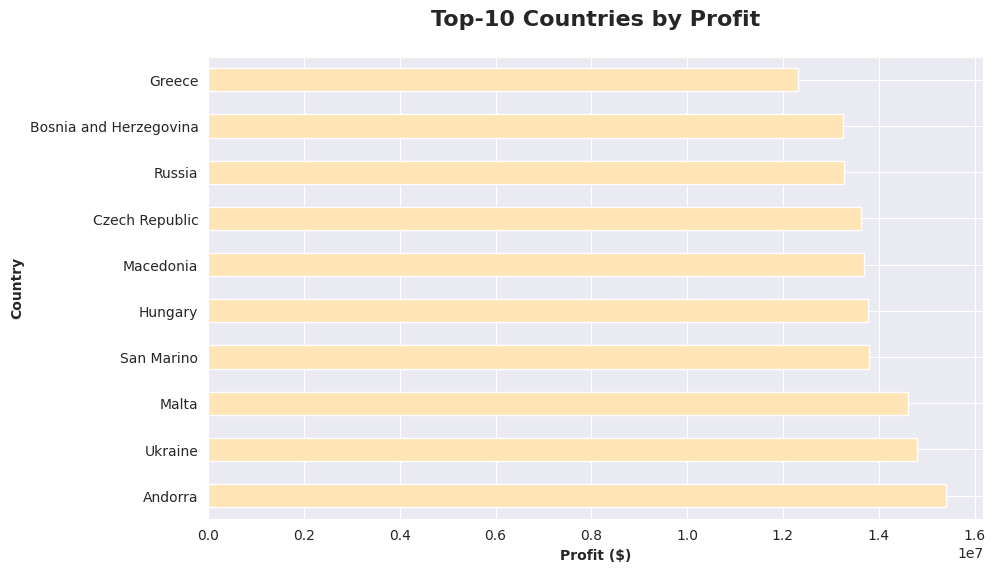

In [ ]:
# countries by profit analysis
country_grouped = df.groupby("country")[["units_sold","revenue","cost","profit"]].sum().sort_values(by="profit",ascending=False).head(10)

plt.figure(figsize=(10,6))
country_grouped['profit'].plot(kind='barh', color='moccasin')

plt.title("Top-10 Countries by Profit", fontsize=16, fontweight="bold", y=1.05)
plt.xlabel("Profit ($)", fontweight="semibold")
plt.ylabel("Country", fontweight="semibold")

plt.show()

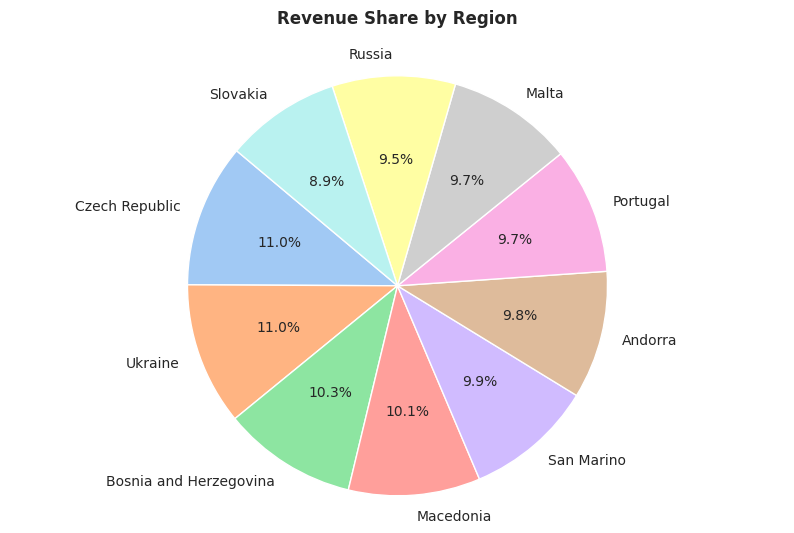

In [ ]:
# countries by revenue analysis
country_revenue_group = df.groupby("country")["revenue"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.pie(
    country_revenue_group,
    labels=country_revenue_group.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette("pastel")
)
plt.title('Revenue Share by Region', fontweight='semibold', y=1.05)
plt.axis('equal')
# plt.tight_layout()
plt.show()

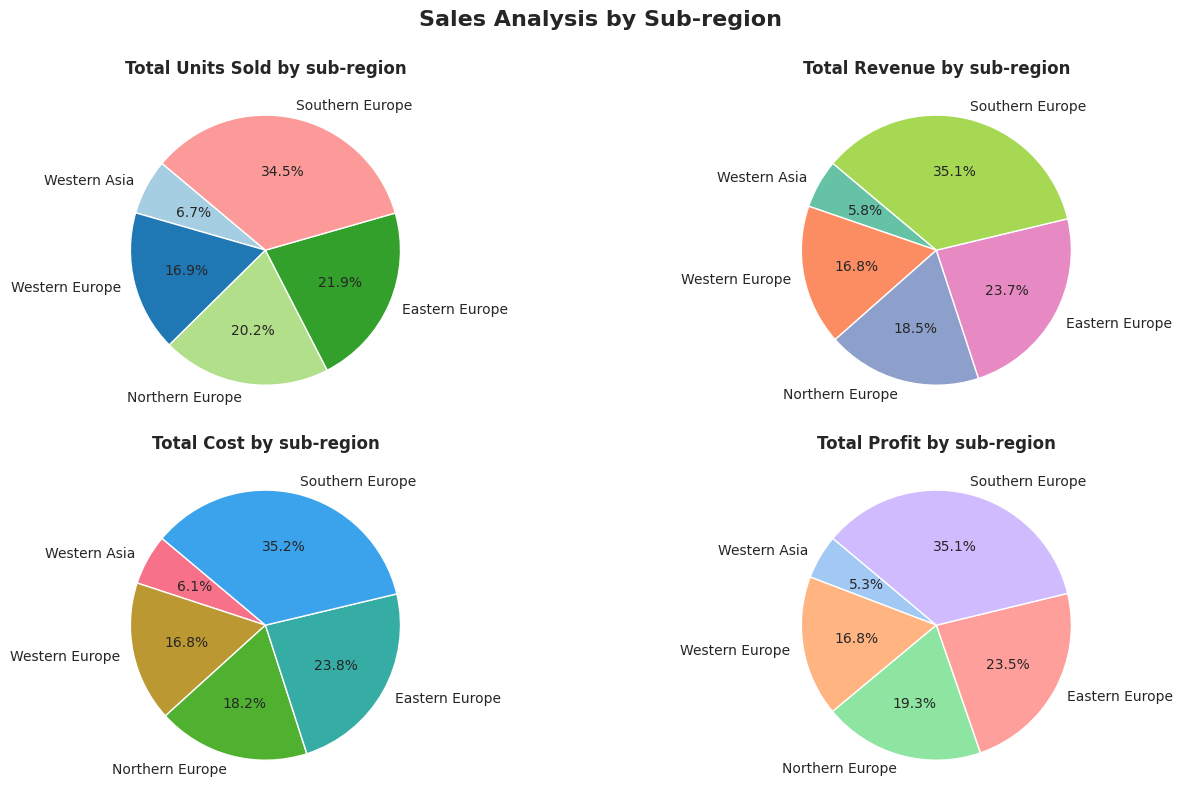

In [ ]:
# sub-region metrics analysis
subregion_units_sold = df.groupby("sub-region")["units_sold"].sum().sort_values(ascending=True)
subregion_profit = df.groupby("sub-region")["profit"].sum().sort_values(ascending=True)
subregion_revenue = df.groupby("sub-region")["revenue"].sum().sort_values(ascending=True)
subregion_cost = df.groupby("sub-region")["cost"].sum().sort_values(ascending=True)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Sales Analysis by Sub-region', fontsize=16, fontweight='bold', y=1)

# Units Sold
axes[0, 0].pie(subregion_units_sold,
    labels=subregion_units_sold.index,
    autopct="%.1f%%",
    startangle=140,
    colors=sns.color_palette("Paired"))

axes[0, 0].set_title('Total Units Sold by sub-region', fontweight='semibold')

# Revenue
axes[0, 1].pie(subregion_revenue,
    labels=subregion_units_sold.index,
    autopct="%.1f%%",
    startangle=140,
    colors=sns.color_palette("Set2"))

axes[0, 1].set_title('Total Revenue by sub-region', fontweight='semibold')

# Cost
axes[1, 0].pie(subregion_cost,
    labels=subregion_units_sold.index,
    autopct="%.1f%%",
    startangle=140,
    colors=sns.color_palette("husl"))

axes[1, 0].set_title('Total Cost by sub-region', fontweight='semibold')

# Profit
axes[1, 1].pie(subregion_profit,
    labels=subregion_profit.index,
    autopct="%.1f%%",
    startangle=140,
    colors=sns.color_palette("pastel"))

axes[1, 1].set_title('Total Profit by sub-region', fontweight='semibold')

plt.tight_layout()
plt.show()

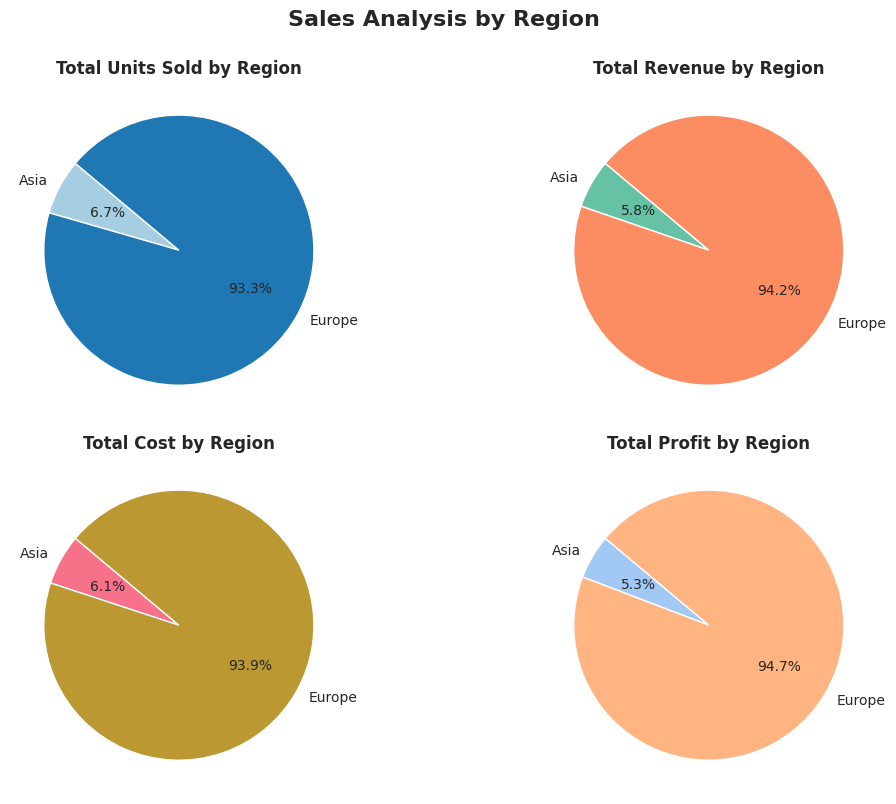

In [ ]:
# region metrics analysis
region_profit = df.groupby("region")["profit"].sum()
region_units = df.groupby("region")["units_sold"].sum()
region_revenue = df.groupby("region")["revenue"].sum()
region_cost = df.groupby("region")["cost"].sum()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Sales Analysis by Region', fontsize=16, fontweight='bold', y=1)

# Units Sold
axes[0, 0].pie(region_units,
    labels=region_units.index,
    autopct="%.1f%%",
    startangle=140,
    colors=sns.color_palette("Paired"))

axes[0, 0].set_title('Total Units Sold by Region', fontweight='semibold')

# Revenue
axes[0, 1].pie(region_revenue,
    labels=region_revenue.index,
    autopct="%.1f%%",
    startangle=140,
    colors=sns.color_palette("Set2"))

axes[0, 1].set_title('Total Revenue by Region', fontweight='semibold')

# Cost
axes[1, 0].pie(region_cost,
    labels=region_cost.index,
    autopct="%.1f%%",
    startangle=140,
    colors=sns.color_palette("husl"))

axes[1, 0].set_title('Total Cost by Region', fontweight='semibold')

# Profit
axes[1, 1].pie(region_profit,
    labels=region_profit.index,
    autopct="%.1f%%",
    startangle=140,
    colors=sns.color_palette("pastel"))

axes[1, 1].set_title('Total Profit by Region', fontweight='semibold')

plt.tight_layout()
plt.show()

### **Report**
**Sales Analysis by Countries**

The *Top-10 Countries by Profit* chart highlights the ten countries generating the highest profit. The leading markets are *Andorra, Ukraine, Malta, San Marino*, and *Hungary*, with profit values ranging between 1e3 and 1e5, indicating consistently strong performance.

The *Revenue Share* chart illustrates the percentage contribution to total revenue among the top-10 countries. The highest shares - *11%* each - are attributed to the *Czech Republic* and *Ukraine*. Bosnia and Herzegovina and North Macedonia each account for 10%, while San Marino contributes *9.9%* of total revenue within the top-10 group.

**Sales Analysis by Sub-region**

The subplots present the percentage distribution of *units sold, revenue, unit cost, and profit* across five sub-regions.

Across all four metrics, *Southern Europe* is the clear leader, accounting for at least *34.5%*, followed by *Eastern Europe* with approximately *23%*.
*Western Asia* represents the smallest share, contributing *6.7%* of *units sold* and only *5.3%* of *total profit*, indicating a relatively limited impact on overall performance.

**Sales Analysis by Region**

The *Sales Analysis by Region* chart compares units sold, revenue, unit cost, and profit across two regions - *Europe* and *Asia*.

*Europe* dominates all metrics, consistently accounting for no less than *93%* of the total.
*Asia* contributes the remaining *5–7%*, highlighting its significantly smaller role in overall sales and profitability.

### **Business Recommendations**
1. Profit is driven by a small set of high-margin countries.
- Top profit countries are relatively small but highly efficient markets operating under a high-margin, low-volume model. The business value here lies in margin preservation rather than aggressive scaling.

2. Revenue-leading countries are critical for cash flow stability.
- Markets with the highest revenue share form the operational backbone of the business. The main risk is volume growth without margin control, making unit economics a key management priority.

3. Southern Europe is the core growth and profit engine.
- The region leads simultaneously in units sold, revenue, and profit, indicating a mature and well-optimized business model. Investments here deliver the highest and most predictable return.

4. Eastern Europe represents the strongest profit-growth opportunity.
- While volumes are solid, profitability lags behind the leader, pointing to room for margin optimization. Targeted improvements in pricing and cost structure could significantly increase profit contribution.

5. The business is highly dependent on Europe.
- With over 93% of all key metrics concentrated in Europe, geographic concentration risk is high. Asia currently plays a secondary role and should be treated as a long-term growth option rather than a core driver.


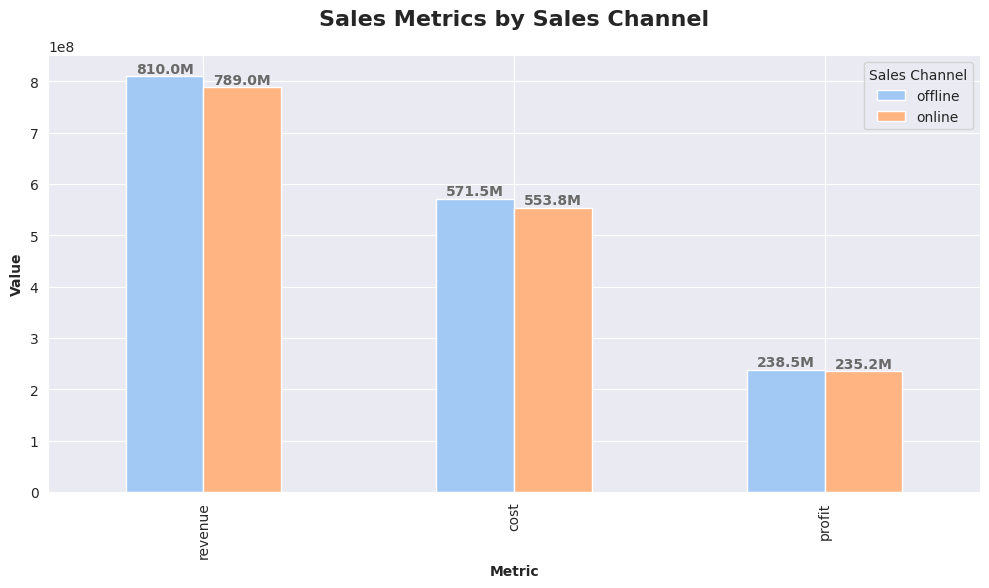

In [ ]:
# sales channels analysis

channel_grouped = df.groupby("sales_channel")[["revenue","cost","profit"]].sum()
palette = sns.color_palette("pastel", n_colors=2)

df_plot = channel_grouped[['revenue','cost','profit']].T
ax = df_plot.plot(kind='bar', figsize=(10,6), color=palette)

plt.xlabel('Metric', fontweight='semibold')
plt.ylabel('Value', fontweight="semibold")
plt.title('Sales Metrics by Sales Channel', fontweight='bold', fontsize=16, y=1.05)
plt.legend(title='Sales Channel')
plt.tight_layout()

for container in ax.containers:
    ax.bar_label(container,
                 labels=[f"{v/1e6:.1f}M" for v in container.datavalues],
                 label_type='edge', fontsize=10, fontweight='semibold', color='dimgrey')

plt.show()

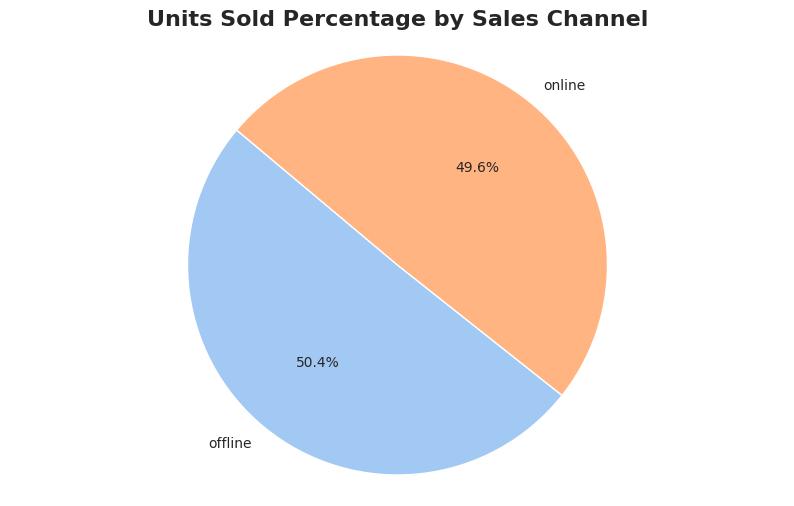

In [ ]:
# sales channel by units sold analysis
channels_units = df.groupby("sales_channel")["units_sold"].sum()
plt.figure(figsize=(10,6))
plt.pie(
    channels_units,
    labels=channels_units.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette("pastel")
)
plt.title('Units Sold Percentage by Sales Channel', fontweight='semibold', fontsize=16, y=1)
plt.axis('equal')
plt.show()

### **Report**
The **Sales Metrics by Sales Channel** chart presents revenue, cost, and profit across two sales channels - online and offline.

The metrics for both channels are nearly identical. Offline sales show a slight advantage in revenue and cost, indicating marginally higher sales volume. At the same time, profit levels are almost equal across channels, suggesting a comparable level of profitability.

The **Units Sold (Share by Sales Channel)** chart further confirms the minimal difference between the channels: offline sales exceed online sales by only about *0.8%*, which is not a significant difference from a business perspective.

### **Business Recommendations**

The minimal difference between online and offline channels across revenue, profit, and units sold indicates a well-balanced sales channel structure with no clear dominance. While offline shows slightly higher volumes, this does not translate into a meaningful profitability advantage, suggesting similar unit economics across channels.

From a business perspective, this implies that shifting budget allocation between channels is unlikely to deliver significant financial impact. Greater value can be achieved by improving channel-level efficiency - optimizing costs, increasing conversion rates, and raising average order value rather than changing the channel mix.

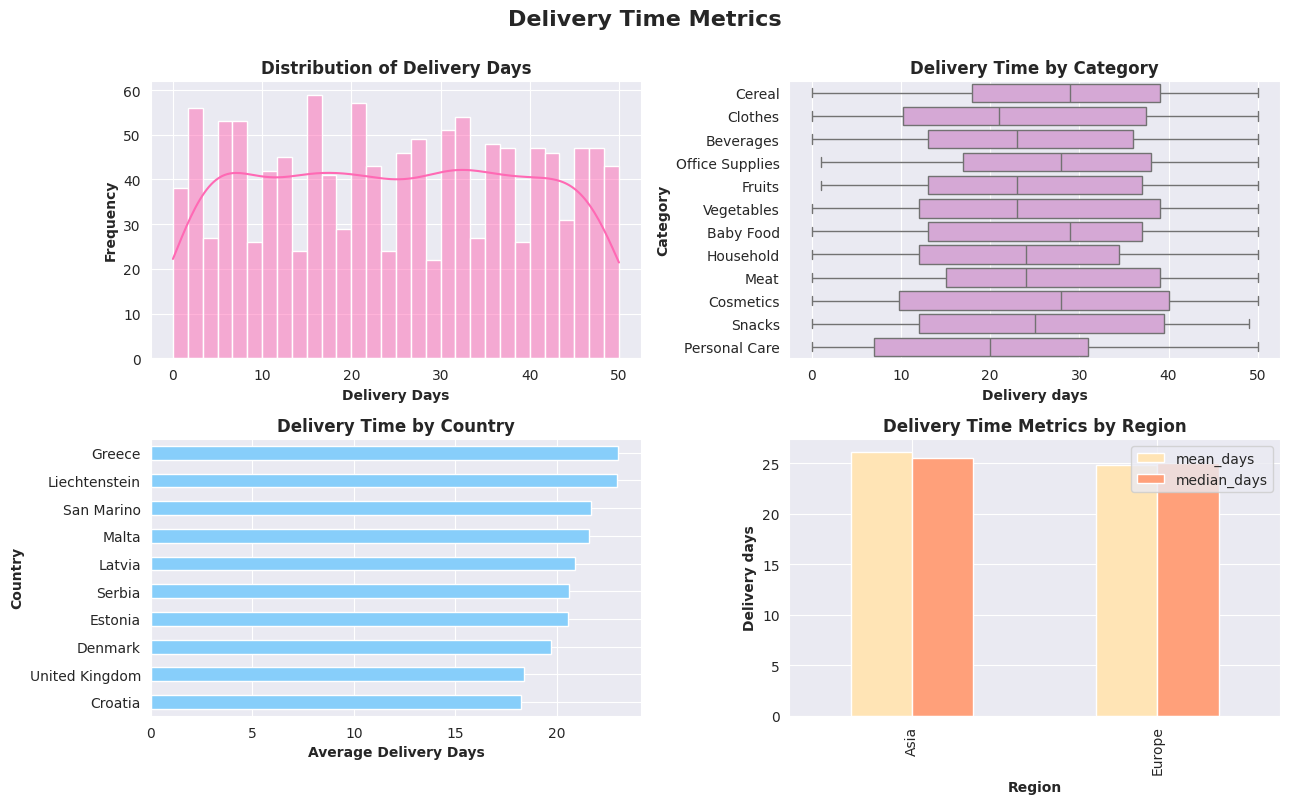

In [ ]:
# delivery time metrics analysis
df["delivery_days"] = (df["ship_date"] - df["order_date"]).dt.days
top10 = df.groupby('country')['delivery_days'].mean().sort_values().head(10)
region_stats = (df.groupby('region')['delivery_days'].agg(mean_days='mean', median_days='median'))

# visualizing delivery time metrics
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle('Delivery Time Metrics', fontweight="bold", fontsize=16, y=1)

# fist subplot
ax = axes[0, 0]

sns.histplot(data=df, x='delivery_days', bins=30, kde=True, color="hotpink", ax=ax)
ax.set(title='Distribution of Delivery Days', xlabel='Delivery Days', ylabel='Frequency')

ax.title.set_fontweight('bold')
ax.xaxis.label.set_fontweight('semibold')
ax.yaxis.label.set_fontweight('semibold')

# second subplot
ax = axes[0, 1]

sns.boxplot(data=df, y='item_type', x='delivery_days', color="plum", ax=ax)
plt.xticks(rotation=45)
ax.set(title='Delivery Time by Category', xlabel='Delivery days', ylabel='Category')

ax.title.set_fontweight('bold')
ax.xaxis.label.set_fontweight('semibold')
ax.yaxis.label.set_fontweight('semibold')

# third subplot
ax = axes[1, 0]
top10.plot(kind='barh', ax=ax, color='lightskyblue')
ax.set(title='Delivery Time by Country', xlabel='Average Delivery Days', ylabel='Country')

ax.title.set_fontweight('bold')
ax.xaxis.label.set_fontweight('semibold')
ax.yaxis.label.set_fontweight('semibold')

# fourth subplot
ax = axes[1, 1]
region_stats[['mean_days', 'median_days']].plot(kind='bar', ax=ax, color=['moccasin', 'lightsalmon'])
ax.set(title='Delivery Time Metrics by Region', xlabel='Region', ylabel='Delivery days')

ax.title.set_fontweight('bold')
ax.xaxis.label.set_fontweight('semibold')
ax.yaxis.label.set_fontweight('semibold')

plt.tight_layout()
plt.show()

### **Report**
**By Product Category:**
- Fastest delivery: *Clothes, Beverages, Baby Food* (~10–25 days).
- Slowest delivery: *Cosmetics, Snacks, Personal Care* (~35–50 days).
- Most categories show high variability → delivery times are inconsistent.

**By Country:**
- Fastest: *United Kingdom, Croatia* (~18 days).
- Slowest: *Greece, Liechtenstein* (~23 days).
- Differences are noticeable but moderate.

**By Region:**
- *Asia* and *Europe* have similar average and median delivery times (~25 days).
- Regional differences are minor; country and category matter more.

### **Business Recommendations**
- Optimize logistics for categories with long delivery times (Cosmetics, Snacks, Personal Care).

- Monitor countries with the slowest delivery times.

- Stable, fast-delivery categories allow better inventory and marketing planning.



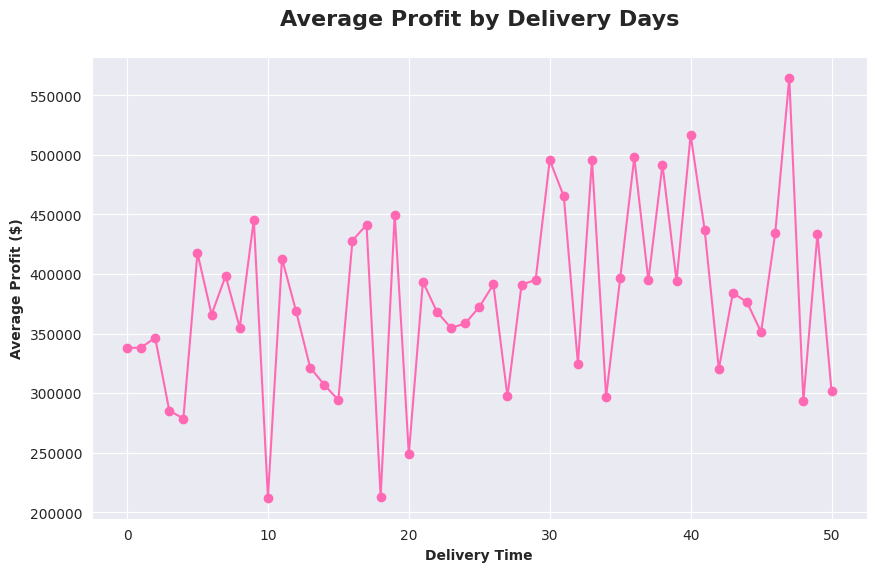

In [ ]:
# delivery days and profit analysis
agg = df.groupby("delivery_days")["profit"].mean()

plt.figure(figsize=(10, 6))
agg.plot(kind="line", marker="o", color="hotpink")
plt.title("Average Profit by Delivery Days", fontsize=16, fontweight="bold", y=1.05)
plt.xlabel("Delivery Time", fontweight="semibold")
plt.ylabel("Average Profit ($)", fontweight="semibold")

plt.show()

### **Report**

Based on the **Average Profit by Delivery Days** chart, there is no clear linear relationship between profit and delivery time. Profit fluctuates significantly across the entire range of delivery days, regardless of whether delivery is fast or slow.

At the same time, higher profit peaks are more frequently observed at medium to longer delivery times (approximately 30–40 days). This likely reflects larger or more margin-intensive orders, where customers are less sensitive to delivery speed.

Short delivery times do not consistently generate higher profit, indicating that delivery speed alone is not a key profitability driver.

### **Business Recommendations**
Delivery time should not be optimized as an isolated KPI. Profitability is primarily driven by order characteristics such as size, product mix, and margin structure rather than shipment speed. Business focus should be placed on order segmentation and unit economics, not on minimizing delivery days.

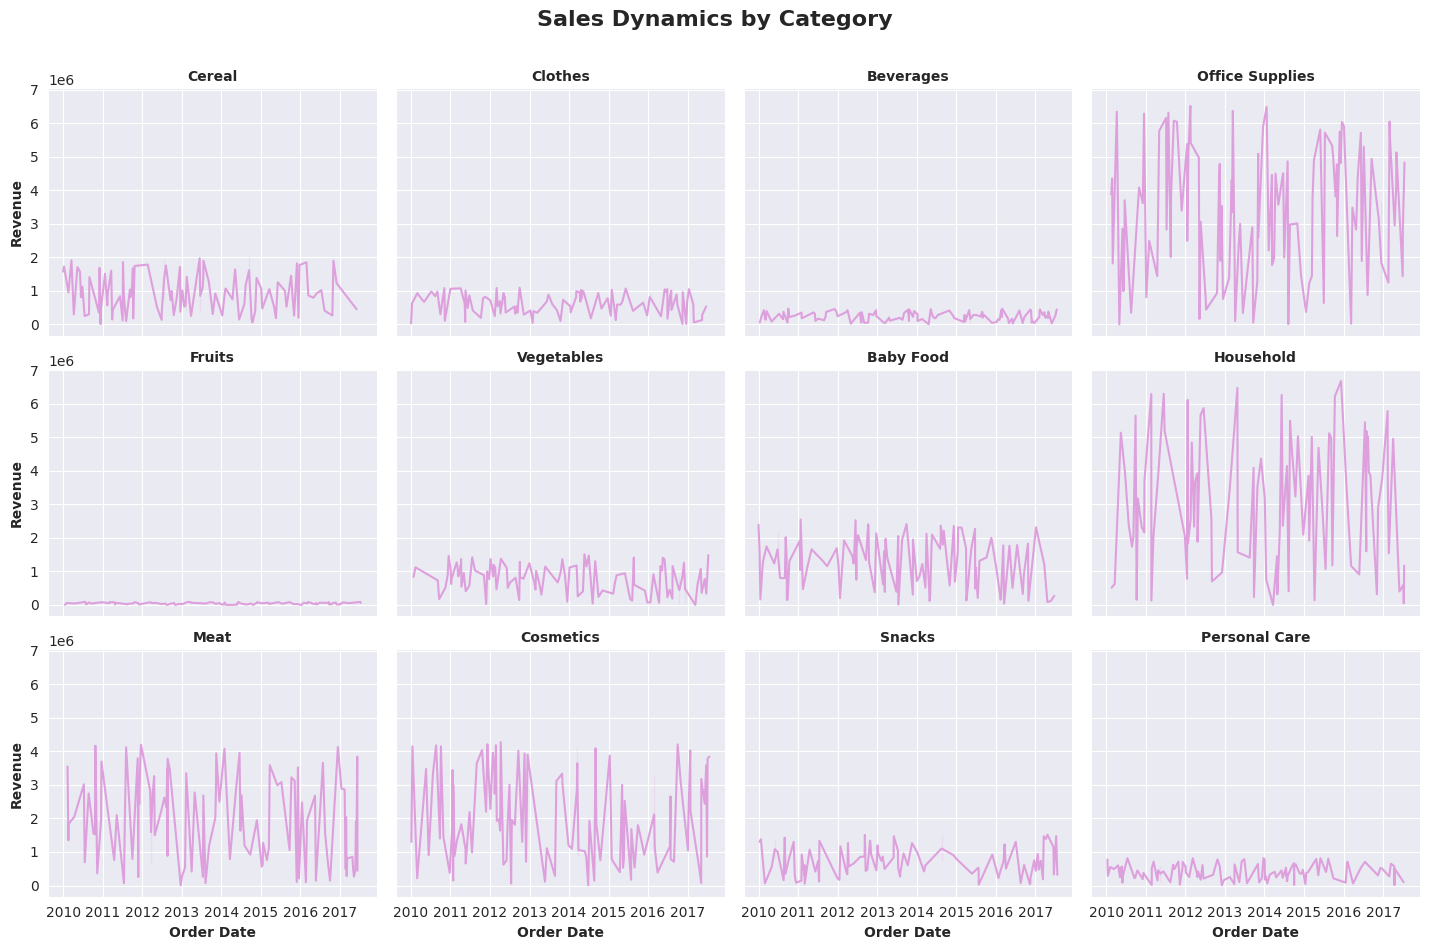

In [ ]:
# sales dynamics analysis
g = sns.relplot(data=df, x='order_date', y='revenue', col='item_type', kind='line', col_wrap=4, height=3, aspect=1.2, color='plum')
g.fig.suptitle("Sales Dynamics by Category", fontsize=16, fontweight='bold', y=1.05)
g.set_axis_labels("Order Date", "Revenue")
g.set_titles("{col_name}")

for ax in g.axes.flatten():
    ax.title.set_fontweight('bold')
    ax.xaxis.label.set_fontweight('semibold')
    ax.yaxis.label.set_fontweight('semibold')

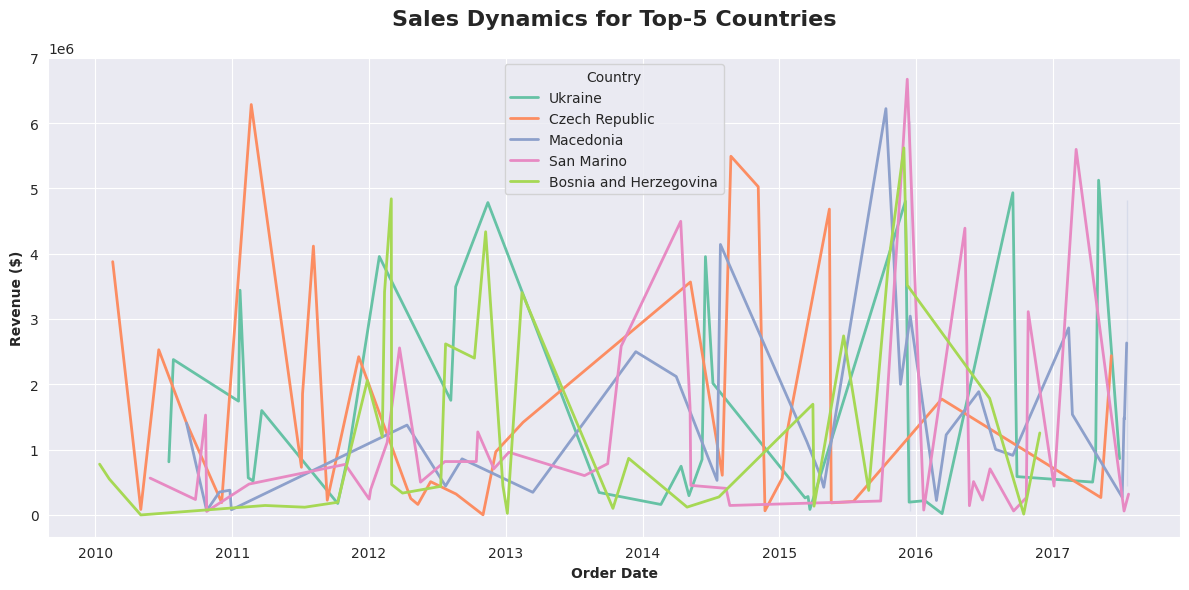

In [ ]:
top_countries = (df.groupby('country')['revenue'].sum().nlargest(5).index)

plt.figure(figsize=(12, 6))
sns.lineplot(data=df[df['country'].isin(top_countries)], x='order_date', y='revenue', hue='country', palette='Set2', linewidth=2)

plt.title("Sales Dynamics for Top-5 Countries", fontsize=16, fontweight="bold", y=1.05)
plt.xlabel("Order Date", fontweight="semibold")
plt.ylabel("Revenue ($)", fontweight="semibold")

plt.legend(title="Country")
plt.tight_layout()
plt.show()

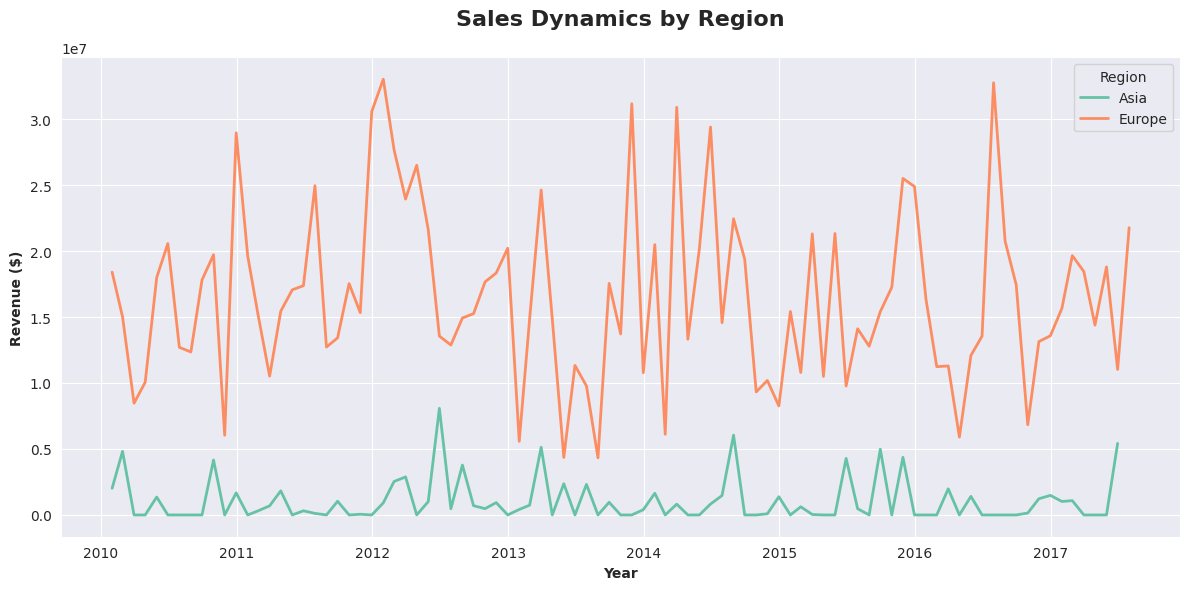

In [ ]:
monthly = (df.set_index('order_date').groupby('region')['revenue'].resample('ME').sum().reset_index())

plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly, x='order_date', y='revenue', hue='region', palette='Set2', linewidth=2)

plt.title("Sales Dynamics by Region", fontsize=16, fontweight="bold", y=1.05)
plt.xlabel("Year", fontweight="semibold")
plt.ylabel("Revenue ($)", fontweight="semibold")

plt.legend(title="Region")
plt.tight_layout()
plt.show()


### **Report**

**By product category**
- Sales across categories evolve unevenly: some categories show stable trends, while others experience sharp fluctuations.
- Several categories act as revenue drivers, consistently contributing the largest share of total sales, while others generate occasional spikes.

**By top-5 countries**
- Leading countries demonstrate clear growth dynamics with visible seasonal fluctuations.
- Differences in amplitude indicate varying market sizes and demand intensity.

**By region**
- With only a few regions, trends are easy to interpret.
- One region shows higher and more stable revenue, while the other is more volatile.


### **Business Recommendations**

- Stable categories are best suited for forecasting and inventory planning, while volatile ones are good candidates for promotions or assortment optimization.
- Top countries represent the main growth opportunities. Marketing and logistics investments should be prioritized in these markets.
- Regional strategies should be differentiated, as demand behavior and revenue scale vary significantly.

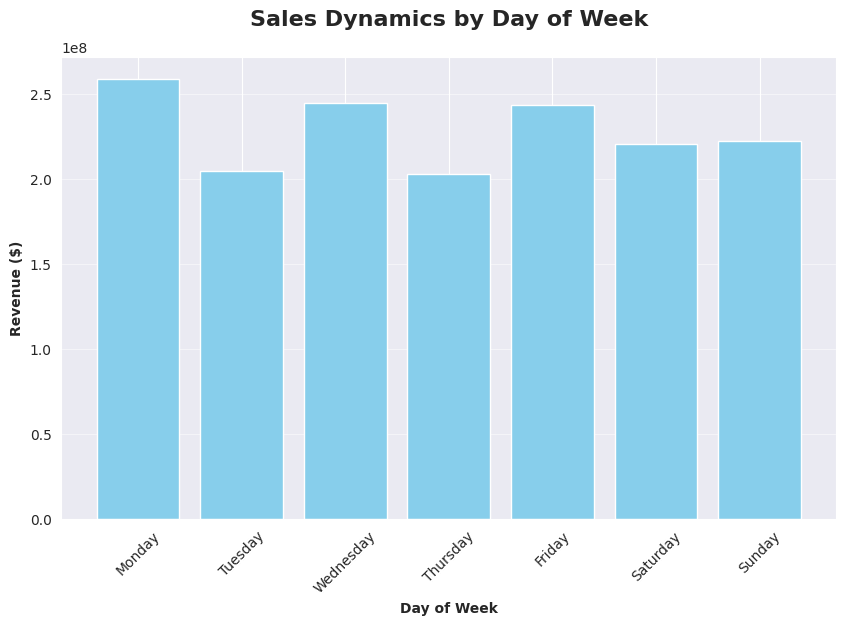

In [ ]:
# dayweek sales analysis
df['day_of_week'] = df['order_date'].dt.day_name()
weekly_revenue = df.groupby('day_of_week')['revenue'].sum().reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])

plt.figure(figsize=(10, 6))
plt.bar(weekly_revenue.index, weekly_revenue.values, color='skyblue')

plt.title("Sales Dynamics by Day of Week", fontsize=16, fontweight="bold", y=1.05)
plt.xlabel("Day of Week", fontweight="semibold")
plt.ylabel("Revenue ($)", fontweight="semibold")
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.5)

plt.show()

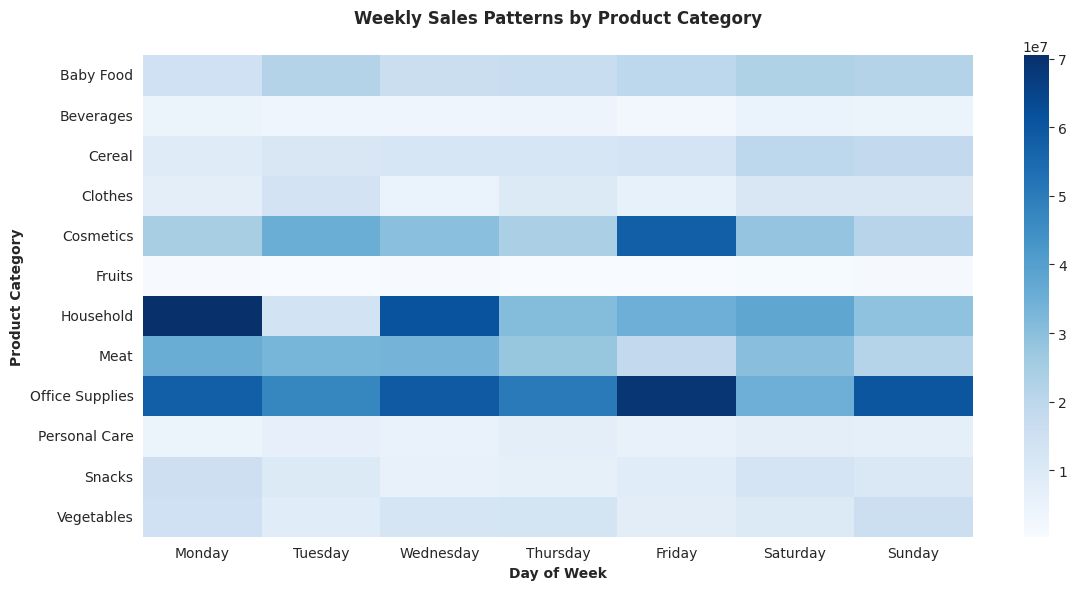

In [ ]:
weekly_item_revenue = (df.groupby(['item_type', 'day_of_week'])['revenue'].sum().reset_index())

pivot = weekly_item_revenue.pivot(index='item_type', columns='day_of_week', values='revenue').reindex(columns=[
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'])

plt.figure(figsize=(12, 6))
sns.heatmap(pivot, cmap='Blues')

plt.title("Weekly Sales Patterns by Product Category", fontweight='bold', y=1.05)
plt.xlabel("Day of Week", fontweight='semibold')
plt.ylabel("Product Category", fontweight='semibold')

plt.tight_layout()
plt.show()

### **Report**
**Sales dynamics by day of week**

The highest sales volumes occur toward the end of the week (Friday–Sunday).

Weekdays show lower but more stable sales levels.

**Weekly sales patterns by product category**

Some product categories consistently perform better on weekends, while others show stronger demand during weekdays.

This reflects weekly behavioral patterns rather than classical seasonality.

### **Business Recommendations**

Peak days require increased operational capacity in inventory management and delivery.

Such products can be considered week-based seasonal. This insight can be used to:
- plan inventory more precisely,
- schedule targeted promotions by day,
- optimize delivery and staffing schedules.